# Stacking Ensemble — Pushing Past 97%

**Idea:** XGBoost, SVM, and Logistic Regression each make *different* errors.  
A meta-learner watches all three and learns which model to trust for each type of case.

| Base model | Why it helps the hard cases |
|------------|----------------------------|
| **XGBoost** | Best overall; tree-based, captures non-linear interactions |
| **SVM (RBF)** | Distance-based boundary; may separate low-cap spam differently |
| **Logistic Regression** | Linear combination of all word frequencies; may catch stealth spam |
| **Meta-learner (LR)** | Learns to combine the three — overrides XGBoost on cases where SVM/LR disagree |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

print('Libraries imported.')

Libraries imported.


## 1. Load Data & Split

In [2]:
df = pd.read_csv('preprocessed_data_v2.csv')
TARGET = 'spam'

engineered_prefixes = [
    'spam_word', 'ham_word', 'spam_ham', 'char_spam',
    'char_ham', 'capital_ratio', 'word_present', 'word_diversity'
]
feature_names = [
    c for c in df.columns
    if c != TARGET and not any(c.startswith(p) for p in engineered_prefixes)
]
X = df[feature_names]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=0
)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

print(f'Features : {len(feature_names)}')
print(f'Train    : {X_train.shape[0]}  |  Test: {X_test.shape[0]}')

Features : 57
Train    : 4049  |  Test: 1013


## 2. Baseline — XGBoost Alone

In [3]:
xgb_base = XGBClassifier(eval_metric='logloss', n_jobs=-1, verbosity=0, random_state=42)
xgb_base.fit(X_train_std, y_train)
pred_base  = xgb_base.predict(X_test_std)
acc_base   = accuracy_score(y_test, pred_base) * 100
fp_base    = int(((y_test == 0) & (pred_base == 1)).sum())
fn_base    = int(((y_test == 1) & (pred_base == 0)).sum())

print(f'XGBoost baseline  →  Test: {acc_base:.3f}%   FP: {fp_base}   FN: {fn_base}')

XGBoost baseline  →  Test: 97.038%   FP: 14   FN: 16


## 3. Base Models — Individual Performance

Check what each model gets right/wrong before stacking.

In [4]:
base_models = {
    'XGBoost'             : XGBClassifier(eval_metric='logloss', n_jobs=-1, verbosity=0, random_state=42),
    'SVM (RBF)'           : SVC(kernel='rbf', probability=True, random_state=42),
    'Logistic Regression' : LogisticRegression(max_iter=2000, random_state=42),
}

base_preds = {}
print(f'{"Model":25s} {"Test Acc":>10} {"FP":>5} {"FN":>5} {"Errors":>8}')
print('-' * 58)
for name, m in base_models.items():
    m.fit(X_train_std, y_train)
    pred = m.predict(X_test_std)
    base_preds[name] = pred
    acc = accuracy_score(y_test, pred) * 100
    fp  = int(((y_test == 0) & (pred == 1)).sum())
    fn  = int(((y_test == 1) & (pred == 0)).sum())
    print(f'{name:25s} {acc:>9.3f}% {fp:>5} {fn:>5} {fp+fn:>8}')

# Show overlap: cases ALL models get wrong (irreducible errors)
all_wrong = np.ones(len(y_test), dtype=bool)
for pred in base_preds.values():
    all_wrong &= (pred != y_test.values)

any_right = np.zeros(len(y_test), dtype=bool)
for pred in base_preds.values():
    any_right |= (pred == y_test.values)

xgb_wrong  = (base_preds['XGBoost'] != y_test.values)
svm_right  = (base_preds['SVM (RBF)'] == y_test.values)
lr_right   = (base_preds['Logistic Regression'] == y_test.values)
recoverable = int((xgb_wrong & (svm_right | lr_right)).sum())

print(f'\nXGBoost errors where SVM or LR is correct : {recoverable} / {fp_base + fn_base}')
print(f'Errors ALL 3 models get wrong (irreducible): {int(all_wrong.sum())}')

Model                       Test Acc    FP    FN   Errors
----------------------------------------------------------
XGBoost                      97.038%    14    16       30
SVM (RBF)                    93.781%    22    41       63
Logistic Regression          93.682%    29    35       64

XGBoost errors where SVM or LR is correct : 15 / 30
Errors ALL 3 models get wrong (irreducible): 15


## 4. Stacking Ensemble

In [5]:
estimators = [
    ('xgb', XGBClassifier(eval_metric='logloss', n_jobs=-1, verbosity=0, random_state=42)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42)),
    ('lr',  LogisticRegression(max_iter=2000, random_state=42)),
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

print('Training stacking ensemble (5-fold CV for meta-features)...')
stack.fit(X_train_std, y_train)

pred_stack  = stack.predict(X_test_std)
proba_stack = stack.predict_proba(X_test_std)
acc_stack   = accuracy_score(y_test, pred_stack) * 100
fp_stack    = int(((y_test == 0) & (pred_stack == 1)).sum())
fn_stack    = int(((y_test == 1) & (pred_stack == 0)).sum())

print(f'\nStacking ensemble  →  Test: {acc_stack:.3f}%   FP: {fp_stack}   FN: {fn_stack}')
print(f'XGBoost baseline   →  Test: {acc_base:.3f}%   FP: {fp_base}   FN: {fn_base}')
print(f'Δ Accuracy : {acc_stack - acc_base:+.3f}%')
print(f'Δ Errors   : {(fp_stack+fn_stack) - (fp_base+fn_base):+d}')

Training stacking ensemble (5-fold CV for meta-features)...

Stacking ensemble  →  Test: 96.940%   FP: 13   FN: 18
XGBoost baseline   →  Test: 97.038%   FP: 14   FN: 16
Δ Accuracy : -0.099%
Δ Errors   : +1


## 5. Results Comparison

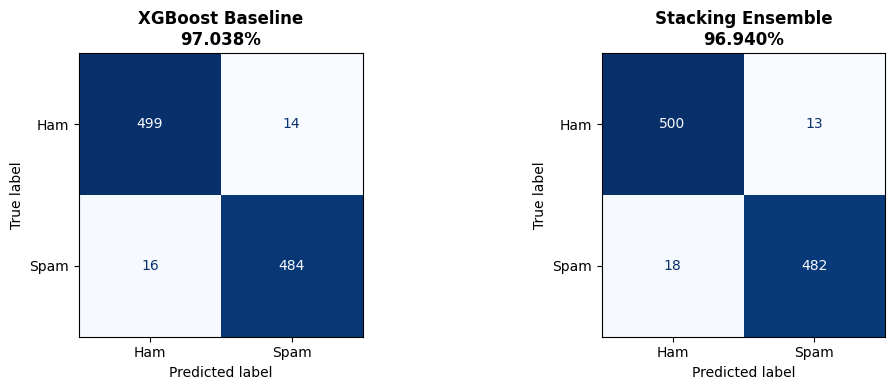

Stacking Ensemble Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      0.97      0.97       513
        Spam       0.97      0.96      0.97       500

    accuracy                           0.97      1013
   macro avg       0.97      0.97      0.97      1013
weighted avg       0.97      0.97      0.97      1013



In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, pred, title in [
    (axes[0], pred_base,  f'XGBoost Baseline\n{acc_base:.3f}%'),
    (axes[1], pred_stack, f'Stacking Ensemble\n{acc_stack:.3f}%'),
]:
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')
plt.tight_layout()
plt.savefig('stacking_cm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Stacking Ensemble Classification Report:')
print(classification_report(y_test, pred_stack, target_names=['Ham', 'Spam']))

## 6. Which XGBoost Errors Did the Ensemble Fix?

In [7]:
xgb_wrong_mask   = pred_base  != y_test.values
stack_wrong_mask = pred_stack != y_test.values

fixed      = int((xgb_wrong_mask & ~stack_wrong_mask).sum())
broken     = int((~xgb_wrong_mask & stack_wrong_mask).sum())
still_wrong= int((xgb_wrong_mask & stack_wrong_mask).sum())

print(f'XGBoost errors fixed by stacking  : {fixed}')
print(f'Correct cases broken by stacking  : {broken}')
print(f'Still wrong in both               : {still_wrong}')
print(f'Net improvement in errors         : {fixed - broken:+d}')
print()

# Analyse the still-wrong cases — are they irreducible?
still_wrong_idx = np.where(xgb_wrong_mask & stack_wrong_mask)[0]
print(f'Cases wrong in ALL models ({int(all_wrong.sum())} identified earlier):')
print(f'Cases still wrong in stack: {still_wrong}')
overlap = int((all_wrong & stack_wrong_mask).sum())
print(f'Overlap (truly irreducible): {overlap}')

XGBoost errors fixed by stacking  : 3
Correct cases broken by stacking  : 4
Still wrong in both               : 27
Net improvement in errors         : -1

Cases wrong in ALL models (15 identified earlier):
Cases still wrong in stack: 27
Overlap (truly irreducible): 15


## 7. Summary

In [8]:
train_acc_stack = accuracy_score(y_train, stack.predict(X_train_std)) * 100
train_acc_base  = accuracy_score(y_train, xgb_base.predict(X_train_std)) * 100

print('=' * 70)
print('STACKING ENSEMBLE SUMMARY')
print('=' * 70)
print(f'{"":30s} {"XGBoost":>10} {"Stacking":>10} {"Change":>10}')
print('-' * 70)
print(f'{"Train Accuracy":30s} {train_acc_base:>9.3f}% {train_acc_stack:>9.3f}% {train_acc_stack-train_acc_base:>+9.3f}%')
print(f'{"Test  Accuracy":30s} {acc_base:>9.3f}% {acc_stack:>9.3f}% {acc_stack-acc_base:>+9.3f}%')
print(f'{"False Positives (Ham→Spam)":30s} {fp_base:>10} {fp_stack:>10} {fp_stack-fp_base:>+10}')
print(f'{"False Negatives (Spam→Ham)":30s} {fn_base:>10} {fn_stack:>10} {fn_stack-fn_base:>+10}')
print(f'{"Total errors":30s} {fp_base+fn_base:>10} {fp_stack+fn_stack:>10} {(fp_stack+fn_stack)-(fp_base+fn_base):>+10}')
print(f'{"Train-Test Gap":30s} {train_acc_base-acc_base:>9.3f}% {train_acc_stack-acc_stack:>9.3f}%')
print('-' * 70)
print(f'XGBoost errors fixed by stack : {fixed}')
print(f'New errors introduced by stack: {broken}')
print(f'Irreducible errors (all wrong) : {int(all_wrong.sum())}')
print('=' * 70)

STACKING ENSEMBLE SUMMARY
                                  XGBoost   Stacking     Change
----------------------------------------------------------------------
Train Accuracy                    99.827%    99.580%    -0.247%
Test  Accuracy                    97.038%    96.940%    -0.099%
False Positives (Ham→Spam)             14         13         -1
False Negatives (Spam→Ham)             16         18         +2
Total errors                           30         31         +1
Train-Test Gap                     2.789%     2.640%
----------------------------------------------------------------------
XGBoost errors fixed by stack : 3
New errors introduced by stack: 4
Irreducible errors (all wrong) : 15
